In [18]:
import os
import time
import tempfile
import subprocess
from collections import Counter


def run_diagonal_walk_unigen(num_samples, D, seed=42, unigen_cmd="unigen"):
    DOMAIN = list(range(0, 11))

    def exactly_one(lits):
        clauses = [list(lits)]
        for i in range(len(lits)):
            for j in range(i + 1, len(lits)):
                clauses.append([-lits[i], -lits[j]])
        return clauses

    def active_domain(center, D):
        lo = max(0, center - D)
        hi = min(10, center + D)
        return list(range(lo, hi + 1))

    def build_problem(current_state=None):
        lit = 1
        decode = {}
        family_lits = {}

        if current_state is None:
            dom0 = DOMAIN
            dom1 = DOMAIN
        else:
            dom0 = active_domain(current_state["x0"], D)
            dom1 = active_domain(current_state["x1"], D)

        for family, dom in (("x0", dom0), ("x1", dom1)):
            lits = []
            for value in dom:
                decode[lit] = (family, value)
                lits.append(lit)
                lit += 1
            family_lits[family] = lits

        clauses = []
        clauses.extend(exactly_one(family_lits["x0"]))
        clauses.extend(exactly_one(family_lits["x1"]))

        # Only allow pairs with x0 + x1 == 11 within the active domains
        for i, a in enumerate(dom0):
            for j, b in enumerate(dom1):
                if a + b != 11:
                    clauses.append([
                        -family_lits["x0"][i],
                        -family_lits["x1"][j],
                    ])

        sampling_set = sorted(decode)
        return clauses, sampling_set, decode

    def write_dimacs(path, clauses, sampling_set, num_vars):
        with open(path, "w") as f:
            f.write("c ind " + " ".join(map(str, sampling_set)) + " 0\n")
            f.write(f"p cnf {num_vars} {len(clauses)}\n")
            for clause in clauses:
                f.write(" ".join(map(str, clause)) + " 0\n")

    def parse_one_assignment(stdout_text):
        for line in stdout_text.splitlines():
            line = line.strip()
            if not line or line.startswith("c"):
                continue

            toks = line.split()
            if toks and all(tok.lstrip("-").isdigit() for tok in toks):
                vals = [int(x) for x in toks]
                if vals and vals[-1] == 0:
                    return vals[:-1]

        raise RuntimeError(f"Could not parse a sample from UniGen output:\n{stdout_text}")

    def decode_sample(sample_lits, decode):
        out = {}
        for lit in sample_lits:
            if lit > 0 and lit in decode:
                family, value = decode[lit]
                out[family] = value
        return out

    current_state = None
    pair_counts = Counter()
    trace_counts = []
    samples = []
    sample_times = []

    for step in range(num_samples):
        clauses, sampling_set, decode = build_problem(current_state=current_state)

        with tempfile.TemporaryDirectory() as tmpdir:
            cnf_path = os.path.join(tmpdir, "problem.cnf")
            write_dimacs(cnf_path, clauses, sampling_set, max(sampling_set))

            step_seed = seed + step
            cmd = [
                unigen_cmd,
                "--samples", "1",
                "--multisample", "1",
                "--seed", str(step_seed),
                cnf_path,
            ]

            t0 = time.perf_counter()
            proc = subprocess.run(
                cmd,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
                check=False,
            )
            elapsed = time.perf_counter() - t0

            if proc.returncode != 0:
                raise RuntimeError(
                    f"UniGen failed\n"
                    f"Command: {cmd}\n"
                    f"STDOUT:\n{proc.stdout}\n"
                    f"STDERR:\n{proc.stderr}"
                )

            sample_lits = parse_one_assignment(proc.stdout)
            s = decode_sample(sample_lits, decode)

        if "x0" not in s or "x1" not in s:
            raise RuntimeError(f"Bad sample decode:\n{proc.stdout}")

        current_state = s
        samples.append(s)
        sample_times.append(elapsed)

        pair_counts[(s["x0"], s["x1"])] += 1
        trace_counts.append(dict(pair_counts))

    total_time = sum(sample_times)
    avg_sample_time = total_time / num_samples if num_samples else 0.0

    return {
        "trace_counts": trace_counts,
        "samples": samples,
        "sample_times": sample_times,
        "avg_sample_time": avg_sample_time,
        "total_time": total_time,
    }


# Example
results = {D: run_diagonal_walk_unigen(num_samples=2000, D=D, seed=42) for D in range(1, 11)}

In [19]:
import numpy as np
import matplotlib.pyplot as plt
Ds=range(1, 11)

DOMAIN = list(range(0, 11))
VALID_PAIRS = [(a, b) for a in DOMAIN for b in DOMAIN if a + b == 11]
K = len(VALID_PAIRS)

def convergence_score(counts_dict, n):
    empirical = np.array([counts_dict.get(p, 0) / n for p in VALID_PAIRS], dtype=float)
    target = np.full(K, 1.0 / K, dtype=float)
    tv = 0.5 * np.abs(empirical - target).sum()
    worst_tv = 1.0 - 1.0 / K
    return 1.0 - tv / worst_tv

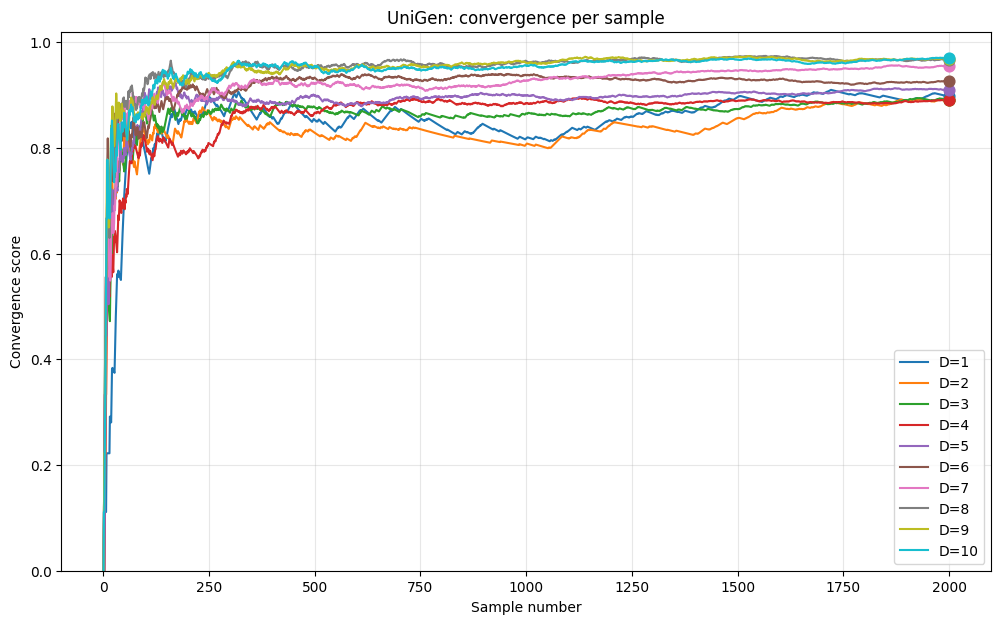

In [20]:
plt.figure(figsize=(12, 7))

for D, data in results.items():
    y = [
        convergence_score(counts_dict, i)
        for i, counts_dict in enumerate(data["trace_counts"], start=1)
    ]
    x = np.arange(1, len(y) + 1)

    line, = plt.plot(x, y, label=f"D={D}")
    plt.scatter([x[-1]], [y[-1]], color=line.get_color(), s=60, zorder=3)

plt.xlabel("Sample number")
plt.ylabel("Convergence score")
plt.title("UniGen: convergence per sample")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

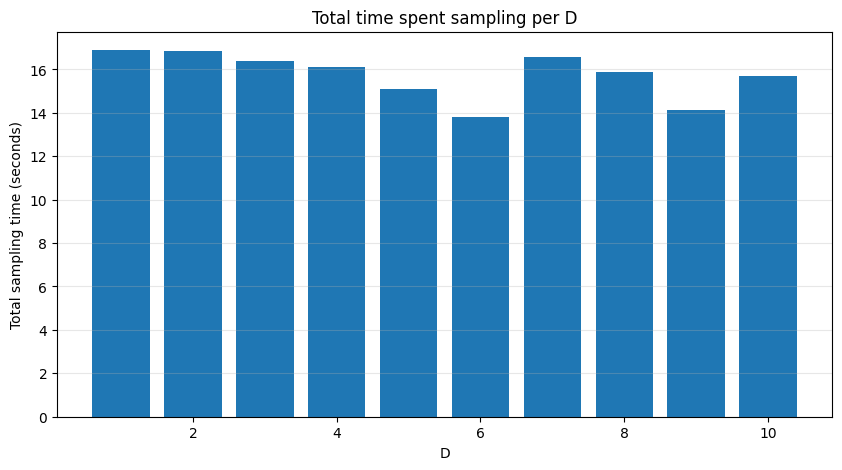

In [21]:
avg_total_times = [results[D]["total_time"] for D in Ds]

plt.figure(figsize=(10, 5))
plt.bar(Ds, avg_total_times)
plt.xlabel("D")
plt.ylabel("Total sampling time (seconds)")
plt.title("Total time spent sampling per D")
plt.grid(True, axis="y", alpha=0.3)
plt.show()